# Lab 10 — MIMO: Diversity, Spatial Multiplexing, Beamforming and Massive MIMO

**Companion to Chapter 10.** The B200 has one TX and one RX chain, so this lab is
simulation-only (a B210 or two synchronized USRPs are needed for over-the-air MIMO).

1. Measure diversity order: MRC with 1, 2 and 4 branches, and Alamouti 2×1.
2. Compute ergodic and outage capacity of MIMO channels, and water-filling.
3. Compare ZF, MMSE, ordered MMSE-SIC and ML detection for 2×2 spatial multiplexing.
4. Steer a uniform linear array, and observe channel hardening in massive MIMO.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
import commlib as cl

cl.style()
rng = np.random.default_rng(10)
qpsk = cl.get_constellation("qpsk")

## 1. Diversity: the slope of the BER curve
With $L$ independent Rayleigh branches and maximum-ratio combining, the BER falls as
$\mathrm{SNR}^{-L}$. Alamouti's 2×1 space-time block code achieves the same order
with two *transmit* antennas and no channel knowledge at the transmitter, but 3 dB
behind 1×2 MRC because the power is split.

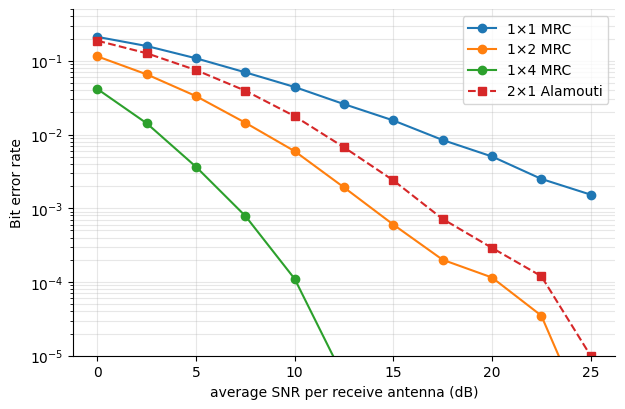

In [3]:
eb = np.arange(0, 26, 2.5)
n = 100_000
bits = cl.random_bits(2 * n, rng); s = qpsk.modulate(bits)
fig, ax = plt.subplots(figsize=(7, 4.5))
for L in [1, 2, 4]:
    ber = []
    for e in eb:
        n0 = 10 ** (-e / 10)
        h = cl.rayleigh_mimo(L, n, rng=rng)
        r = h * s + np.sqrt(n0 / 2) * (rng.standard_normal((L, n)) + 1j * rng.standard_normal((L, n)))
        ber.append(np.mean(qpsk.demodulate(cl.mrc(r, h)) != bits))
    ax.semilogy(eb, np.maximum(ber, 1e-6), "o-", label=f"1×{L} MRC")
ber = []
for e in eb:
    n0 = 10 ** (-e / 10)
    tx = cl.alamouti_encode(s)
    hb = cl.rayleigh_mimo(n // 2, 2, rng=rng)                  # one channel per 2-symbol block
    hfull = np.repeat(hb, 2, axis=0)
    r = np.sum(hfull.T * tx, axis=0) + np.sqrt(n0 / 2) * (rng.standard_normal(n) + 1j * rng.standard_normal(n))
    ber.append(np.mean(qpsk.demodulate(cl.alamouti_decode(r, hb)) != bits))
ax.semilogy(eb, np.maximum(ber, 1e-6), "s--", label="2×1 Alamouti")
cl.ber_axes(ax, "average SNR per receive antenna (dB)"); ax.set_ylim(1e-5, 0.5); ax.legend(); plt.show()

## 2. MIMO capacity
For $\mathbf{y} = \mathbf{H}\mathbf{x} + \mathbf{n}$ with no transmit CSI,
$C = \log_2\det(\mathbf{I} + \frac{\rho}{N_t}\mathbf{H}\mathbf{H}^H)$. At high SNR,
capacity grows as $\min(N_t, N_r)\log_2\rho$: the multiplexing gain.

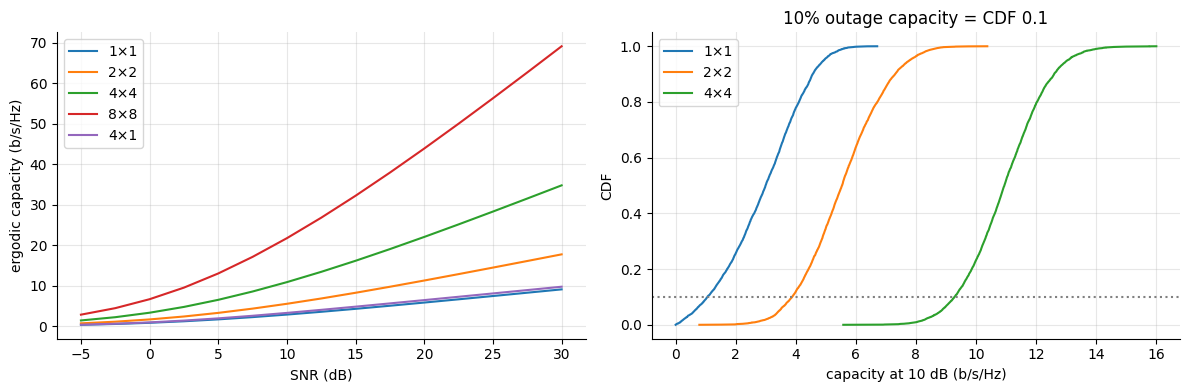

In [5]:
snr_db = np.arange(-5, 31, 2.5)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for nt, nr in [(1, 1), (2, 2), (4, 4), (8, 8), (4, 1)]:
    H = cl.rayleigh_mimo(nr, nt, n=2000, rng=rng)
    C = [np.mean(cl.capacity_equal_power(H, 10 ** (x / 10))) for x in snr_db]
    ax[0].plot(snr_db, C, label=f"{nt}×{nr}")
ax[0].set_xlabel("SNR (dB)"); ax[0].set_ylabel("ergodic capacity (b/s/Hz)"); ax[0].legend()
for nt, nr in [(1, 1), (2, 2), (4, 4)]:
    H = cl.rayleigh_mimo(nr, nt, n=5000, rng=rng)
    C = np.sort(cl.capacity_equal_power(H, 10))
    ax[1].plot(C, np.arange(1, len(C) + 1) / len(C), label=f"{nt}×{nr}")
ax[1].set_xlabel("capacity at 10 dB (b/s/Hz)"); ax[1].set_ylabel("CDF"); ax[1].set_title("10% outage capacity = CDF 0.1")
ax[1].axhline(0.1, color="gray", ls=":"); ax[1].legend(); plt.tight_layout(); plt.show()

### Interactive: SVD precoding and water-filling
With channel knowledge at the transmitter, $\mathbf{H} = \mathbf{U}\Sigma\mathbf{V}^H$
decomposes the link into parallel eigen-channels. Water-filling pours power into the
strongest ones. Antenna correlation (ρ) shrinks the weaker singular values.

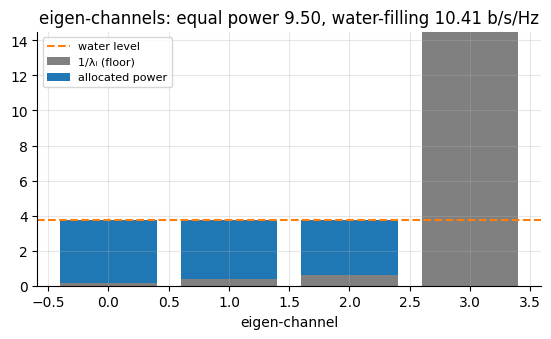

In [7]:
def wf_demo(nt=4, snr_db=10.0, rho=0.0, seed=0):
    H = cl.correlated_mimo(nt, nt, rho, rho, rng=np.random.default_rng(seed))
    g = np.linalg.svd(H, compute_uv=False) ** 2
    P = 10 ** (snr_db / 10)
    p = cl.waterfill(g, P)
    fig, ax = plt.subplots(figsize=(6.5, 3.3))
    base = 1 / g
    ax.bar(range(nt), base, color="gray", label="1/λᵢ (floor)")
    ax.bar(range(nt), p, bottom=base, color="C0", label="allocated power")
    ax.axhline((P + np.sum(base[p > 0])) / max(np.sum(p > 0), 1), color="C1", ls="--", label="water level")
    ce = cl.capacity_equal_power(H, P); cw = cl.capacity_waterfilling(H, P)
    ax.set_title(f"eigen-channels: equal power {ce:.2f}, water-filling {cw:.2f} b/s/Hz")
    ax.set_xlabel("eigen-channel"); ax.legend(fontsize=8); ax.set_ylim(0, min(ax.get_ylim()[1], 5 * P / nt + 2))
    plt.show()

interact(wf_demo, nt=IntSlider(value=4, min=2, max=8), snr_db=FloatSlider(value=10, min=-10, max=30, step=1),
         rho=FloatSlider(value=0.0, min=0, max=0.99, step=0.05), seed=IntSlider(value=0, min=0, max=20));

## 3. Detection for spatial multiplexing
Two QPSK streams over 2×2 Rayleigh. ZF inverts H and suffers noise enhancement
(diversity order $N_r - N_t + 1 = 1$); MMSE regularizes; ordered MMSE-SIC (V-BLAST)
cancels the strongest stream first; ML achieves full receive diversity at
exponential cost. Practical receivers use sphere decoding or K-best in between.

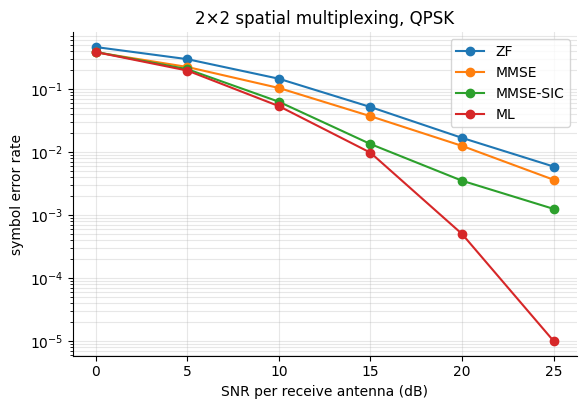

In [9]:
eb = np.arange(0, 26, 5)
res = {k: [] for k in ["ZF", "MMSE", "MMSE-SIC", "ML"]}
trials = 4000
for e in eb:
    n0 = 2 * 10 ** (-e / 10)          # SNR per receive antenna = total TX power / n0
    errs = {k: 0 for k in res}
    for _ in range(trials):
        H = cl.rayleigh_mimo(2, 2, rng=rng)
        x = qpsk.points[rng.integers(0, 4, 2)]
        y = H @ x + np.sqrt(n0 / 2) * (rng.standard_normal(2) + 1j * rng.standard_normal(2))
        errs["ZF"] += np.sum(qpsk.decide(cl.zf_detect(H, y)) != x)
        errs["MMSE"] += np.sum(qpsk.decide(cl.mmse_detect(H, y, n0)) != x)
        errs["MMSE-SIC"] += np.sum(cl.mmse_sic_detect(H, y, n0, qpsk.points) != x)
        errs["ML"] += np.sum(cl.ml_detect(H, y, qpsk.points) != x)
    for k in res:
        res[k].append(errs[k] / (2 * trials))
fig, ax = plt.subplots(figsize=(6.5, 4.2))
for k, v in res.items():
    ax.semilogy(eb, np.maximum(v, 1e-5), "o-", label=k)
cl.ber_axes(ax, "SNR per receive antenna (dB)"); ax.set_ylabel("symbol error rate"); ax.legend()
ax.set_title("2×2 spatial multiplexing, QPSK"); plt.show()

## 4. Beamforming with a uniform linear array
Conjugate (matched) beamforming weights $\mathbf{w} = \mathbf{a}(\theta_0)$ give an
array gain of $N$ in the look direction. A taper (e.g. Chebyshev or Taylor) trades
main-lobe width for lower sidelobes. Element spacing above $\lambda/2$ creates grating lobes.

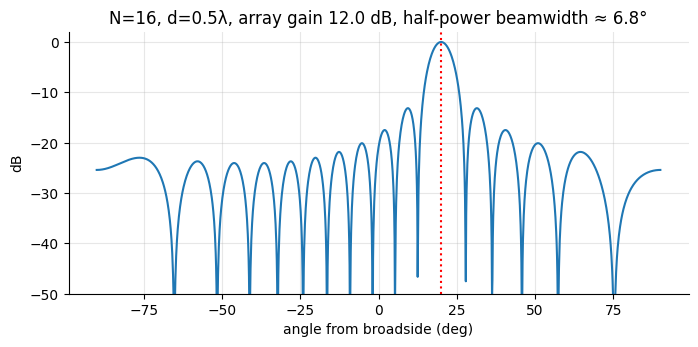

In [11]:
from scipy.signal.windows import chebwin
def beam(n=16, steer_deg=20.0, spacing=0.5, taper="uniform"):
    th = np.deg2rad(np.linspace(-90, 90, 1441))
    w = cl.ula_steering(n, np.deg2rad(steer_deg), spacing)[:, 0]
    if taper == "Chebyshev 30 dB":
        w = w * chebwin(n, 30)
    af = cl.array_factor_db(w, th, spacing)
    fig, ax = plt.subplots(figsize=(8, 3.4))
    ax.plot(np.rad2deg(th), af); ax.set_ylim(-50, 2); ax.set_xlabel("angle from broadside (deg)")
    ax.set_ylabel("dB"); ax.axvline(steer_deg, color="r", ls=":")
    ax.set_title(f"N={n}, d={spacing}λ, array gain {10*np.log10(n):.1f} dB, "
                 f"half-power beamwidth ≈ {np.rad2deg(0.886/(n*spacing*np.cos(np.deg2rad(steer_deg)))):.1f}°")
    plt.show()

interact(beam, n=IntSlider(value=16, min=2, max=64), steer_deg=FloatSlider(value=20, min=-80, max=80, step=1),
         spacing=FloatSlider(value=0.5, min=0.1, max=1.5, step=0.05),
         taper=Dropdown(options=["uniform", "Chebyshev 30 dB"]));

## 5. Massive MIMO: channel hardening and favourable propagation
With $M$ base-station antennas and i.i.d. channels, $\|\mathbf{h}\|^2/M \to 1$ and
$\mathbf{h}_1^H\mathbf{h}_2/M \to 0$: the effective channel stops fading and users
become orthogonal, so simple matched-filter processing approaches optimal
(Marzetta, 2010). Real arrays see correlation, which slows both effects.

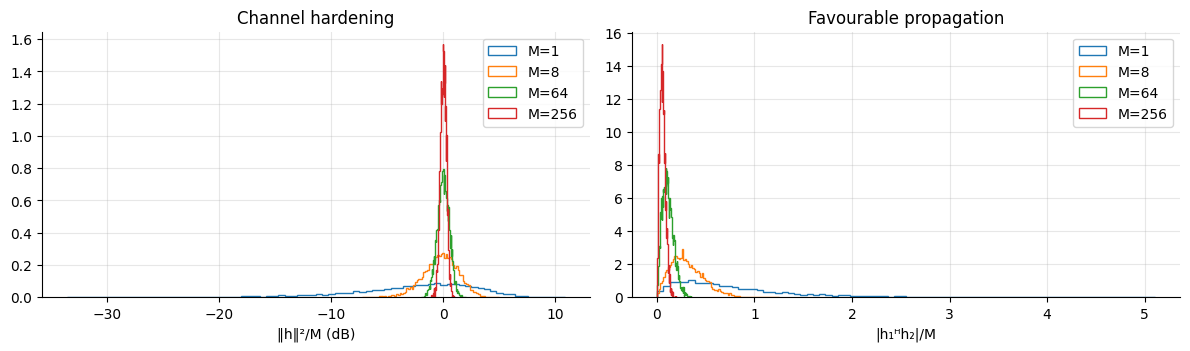

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for M in [1, 8, 64, 256]:
    h = cl.rayleigh_mimo(M, 1, n=5000, rng=rng)[:, :, 0]
    g = np.sum(np.abs(h) ** 2, axis=1) / M
    ax[0].hist(10 * np.log10(g), bins=80, density=True, histtype="step", label=f"M={M}")
    h2 = cl.rayleigh_mimo(M, 1, n=5000, rng=rng)[:, :, 0]
    ip = np.abs(np.sum(np.conj(h) * h2, axis=1)) / M
    ax[1].hist(ip, bins=80, density=True, histtype="step", label=f"M={M}")
ax[0].set_xlabel("‖h‖²/M (dB)"); ax[0].set_title("Channel hardening"); ax[0].legend()
ax[1].set_xlabel("|h₁ᴴh₂|/M"); ax[1].set_title("Favourable propagation"); ax[1].legend()
plt.tight_layout(); plt.show()

## Exercises
1. **(Warm-up)** Derive the 3 dB gap between Alamouti 2×1 and MRC 1×2.
2. **(Core)** Implement a K-best sphere decoder for 4×4 16-QAM and plot its BER and
   average number of visited nodes against ML and MMSE-SIC.
3. **(Core)** Add estimation error to H (MMSE estimate from $N_p$ pilots) and show how
   ZF and MMSE degrade with $N_p$.
4. **(Stretch)** Simulate a 64-antenna base station serving 8 single-antenna users with
   maximum-ratio, ZF and regularized-ZF precoding. Plot sum rate versus SNR and
   explain where each wins.